<a href="https://colab.research.google.com/github/mukul-mschauhan/deep-learning/blob/main/Neural_Network_on_MNIST_Dataset_Using_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q keras

In [2]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
%matplotlib inline

### About Dataset

* x_train: uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data. Pixel values range from 0 to 255.

* y_train: uint8 NumPy array of digit labels (integers in range 0-9) with shape (60000,) for the training data.

* x_test: uint8 NumPy array of grayscale image data with shapes (10000, 28, 28), containing the test data. Pixel values range from 0 to 255.

* y_test: uint8 NumPy array of digit labels (integers in range 0-9) with shape (10000,) for the test data.

In [4]:
(xtrain, ytrain), (xtest, ytest) = mnist.load_data()

In [13]:
type(xtrain), type(ytrain)

(numpy.ndarray, numpy.ndarray)

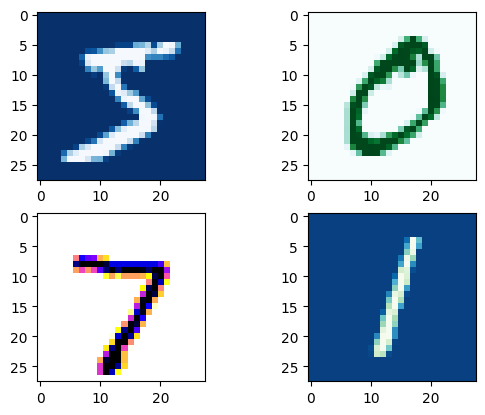

In [28]:
# List of Cmaps : GnBu, GnBu_r, Greens, gist_rainbow_r, gnuplot2_r, Greens_r, Blues_r,'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r'

plt.subplot(221)
plt.imshow(xtrain[0], cmap=plt.get_cmap('Blues_r'))
plt.subplot(222)
plt.imshow(xtrain[1], cmap=plt.get_cmap('BuGn'))
plt.subplot(223)
plt.imshow(xtest[0], cmap=plt.get_cmap('gnuplot2_r'))
plt.subplot(224)
plt.imshow(xtest[2], cmap=plt.get_cmap('GnBu_r'))

In [47]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings("ignore")

In [40]:
num_pixels = xtrain.shape[1]*xtrain.shape[2]

# Reshape the Input for NN Model
xtrain_reshaped = xtrain.reshape(xtrain.shape[0], num_pixels).astype("float32")
xtest_reshaped = xtest.reshape(xtest.shape[0], num_pixels).astype("float32")

# Scale the Inputs
newxtrain = xtrain_reshaped/255
newxtest = xtest_reshaped/255

In [43]:
y_train = to_categorical(ytrain)
y_test = to_categorical(ytest)
num_classes = y_test.shape[1]

In [48]:
# buildng the model
model = Sequential()
# add 1000 units in the hidden layer
# apply relu activation in hidden layer
model.add(Dense(1000, input_dim=num_pixels,activation='relu'))
# initialize the output layer
model.add(Dense(num_classes, activation='softmax'))
# compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# extract the summary of model
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 1000)                │         785,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │          10,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

None


In [49]:
model.fit(newxtrain, y_train, validation_data=(newxtest, y_test),
          epochs=10, batch_size=1024, verbose=1)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.7683 - loss: 0.8432 - val_accuracy: 0.9338 - val_loss: 0.2345
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9395 - loss: 0.2127 - val_accuracy: 0.9539 - val_loss: 0.1626
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9572 - loss: 0.1512 - val_accuracy: 0.9620 - val_loss: 0.1307
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9686 - loss: 0.1115 - val_accuracy: 0.9678 - val_loss: 0.1113
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9756 - loss: 0.0887 - val_accuracy: 0.9721 - val_loss: 0.0948
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9804 - loss: 0.0722 - val_accuracy: 0.9748 - val_loss: 0.0837
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9849 - loss: 0.0586 - val_accuracy: 0.9774 - val_loss: 0.0751
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9875 - loss: 0.0485 - val_accuracy: 0.9775 - v